前回用いた、Jena Climate Datasetに対して、精度の向上を目指す
前回で一番良かったモデルはlstm_oneのモデルで、0.06879843523104985(Huber loss)であった。
この精度(波形をしっかりとらえることができる)をより上げることに焦点を当てる

前処理までは、前と同じなので説明は省略

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import math

In [18]:
df=pd.read_csv("jena_climate_2009_2016.csv")
df['day']=pd.to_datetime(df['Date Time'],dayfirst=True)
df.drop("Date Time",axis=1,inplace=True)
df_day = df.resample('D', on='day').mean().reset_index()
df_nan_rows = df_day[df_day.isnull().any(axis=1)]
ideal_range = pd.date_range(start=df_day['day'].min(), end=df_day['day'].max(), freq='D')
df_indexed = df_day.set_index('day').reindex(ideal_range)
missing_dates = df_indexed[df_indexed.isnull().any(axis=1)].index
df_nonan = df_indexed.interpolate(method='linear')
df_p=df_nonan.reset_index().rename({'index':"day"},axis=1)
timestamp_s = df_p.day.map(pd.Timestamp.timestamp) 
day_seconds = 24 * 60 * 60
year_seconds = (365.2425) * day_seconds
df_p['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_seconds))
df_p['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_seconds))
wd_rad = df_p['wd (deg)'] * np.pi / 180
df_p['Wx'] = df_p['wv (m/s)'] * np.cos(wd_rad)
df_p['Wy'] = df_p['wv (m/s)'] * np.sin(wd_rad)
cols_to_drop = [
    'day', 
    'wv (m/s)', 'max. wv (m/s)', 'wd (deg)',
    'Tpot (K)', 'Tdew (degC)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)'
]
df_final = df_p.drop(columns=cols_to_drop)
n = len(df_final)
train_df = df_final[0:int(n*0.7)]
val_df = df_final[int(n*0.7):int(n*0.9)]
test_df = df_final[int(n*0.9):]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

print("Trainデータの形状:", train_scaled.shape)
print("Valデータの形状:", val_scaled.shape)
print("Testデータの形状:", test_scaled.shape)
train_df = pd.DataFrame(train_scaled, columns=df_final.columns, index=train_df.index)
val_df = pd.DataFrame(val_scaled, columns=df_final.columns, index=val_df.index)
test_df = pd.DataFrame(test_scaled, columns=df_final.columns, index=test_df.index)

class data_load(Dataset):
    def __init__(self,df,input_width,label_width,shift,label_col=None):
        self.df=df
        self.input_width=input_width
        self.label_width=label_width
        self.total_window_size=input_width+shift
        self.label_columns=label_col
        if label_col is not None:
            col_ind={name:i for i,name in  enumerate(df.columns)}
            self.lab_ind=[col_ind[name] for name in self.label_columns]
        self.data = torch.tensor(df.values.astype('float32'))
    def __len__(self):
        return len(self.data)-self.total_window_size+1
    
    def __getitem__(self, i):
        window=self.data[i:i+self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, :]
        if self.label_columns is not None:
            labels=labels[:,self.lab_ind]
        return inputs,labels

def create_dataloader(df, input_width=7, label_width=7, shift=7, batch_size=32, shuffle=False):
    dataset = data_load(
        df=df, 
        input_width=input_width, 
        label_width=label_width, 
        shift=shift, 
        label_col=label_cols  
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return dataloader

label_cols=['T (degC)']
train_loader = create_dataloader(
    df=train_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=True
)
val_loader = create_dataloader(
    df=val_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)
test_loader = create_dataloader(
    df=test_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)

Trainデータの形状: (2046, 8)
Valデータの形状: (584, 8)
Testデータの形状: (293, 8)


ここで、モデル選択について考える。
前回のモデルをただ足して、CNN+LSTMをつくるのは得策ではないと判断。
理由としては、前回のCNNモデルでは、convを2回通しているのでシーケンス長が、3しかない。
そうすると本来の強みであるlstmの長期記憶の要素が減る。
なので、一回cnnに通して、その後lstmに通すというモデルを作る

In [19]:
class time_ser(nn.Module):
    def __init__(self, in_cha, conv_cha):
        super().__init__()
        self.conv1 = nn.Conv1d(in_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.avgpool = nn.MaxPool1d(2, 2)
    
    def forward(self, input):
        block_out = self.conv1(input)
        block_out = self.relu1(block_out)
        block_out = self.conv2(block_out)
        block_out = self.relu2(block_out)
        return self.avgpool(block_out)

class CNN_LSTM_SingleConv(nn.Module):
    def __init__(self, in_cha=8, conv_cha=32, lstm_hidden=64, lstm_layers=1,dropout_rate=0.0):
        super().__init__()
        self.block1 = time_ser(in_cha, conv_cha) # [B, 8, 14] -> [B, 32, 7]
        self.dropout_cnn = nn.Dropout(p=dropout_rate)
        self.lstm = nn.LSTM(
            input_size=conv_cha,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True
        )
        self.dropout_lstm = nn.Dropout(p=dropout_rate)
        self.head_linear = nn.Linear(lstm_hidden, 14)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu'
                )
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)

    def forward(self, input_batch):
        # [B, 14, 8] -> [B, 8, 14]
        input_batch = input_batch.permute(0, 2, 1)
        
        block_out = self.block1(input_batch)  # 出力: [B, 32, 7]
        block_out = self.dropout_cnn(block_out)
        # LSTM向けに次元入れ替え: [B, 32, 7] -> [B, 7, 32]
        lstm_input = block_out.permute(0, 2, 1)
        lstm_out, (h_n, c_n) = self.lstm(lstm_input)
        out = h_n[-1] # [B, 64]
        out = self.dropout_lstm(out)
        linear_output = self.head_linear(out)
        kekka = linear_output.unsqueeze(-1)
        return kekka

In [20]:
model= CNN_LSTM_SingleConv().to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
#loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model_cnn_lstm.pth" 

for i in range(epoch):
    model.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)#勾配爆発対策
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step()
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path) 
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break

model.load_state_dict(torch.load(best_model_path))


Epoch 1/50 | Train Loss: 0.1060 | Val Loss: 0.0804
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0777 | Val Loss: 0.0755
ベストモデルを更新
Epoch 3/50 | Train Loss: 0.0736 | Val Loss: 0.0844
Val Loss改善せず (Patience: 1/5)
Epoch 4/50 | Train Loss: 0.0726 | Val Loss: 0.0776
Val Loss改善せず (Patience: 2/5)
Epoch 5/50 | Train Loss: 0.0707 | Val Loss: 0.0872
Val Loss改善せず (Patience: 3/5)
Epoch 6/50 | Train Loss: 0.0683 | Val Loss: 0.0815
Val Loss改善せず (Patience: 4/5)
Epoch 7/50 | Train Loss: 0.0669 | Val Loss: 0.0799
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 7 で学習を早期終了します。


<All keys matched successfully>

In [21]:
with torch.no_grad():
    model.eval()
    test_loss4=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model(inputs)
        loss=loss_fn(outputs,labels)
        test_loss4+=loss.item()
    test_loss4=test_loss4/len(test_loader)
test_loss4

0.07041442435648707

結論、モデルの精度向上にはつながらなかった。
裏でいろいろモデルをいじってみた(損失関数をmseにかえる、)が、精度(波形を捉える)ことはできなかった。
恐らく考えるに、モデルが問題というよりかは、モデルに対して、データ数がすくないかつ、2週間先は予測が難しいということだろう。
今度は大規模データで、試してみたい。

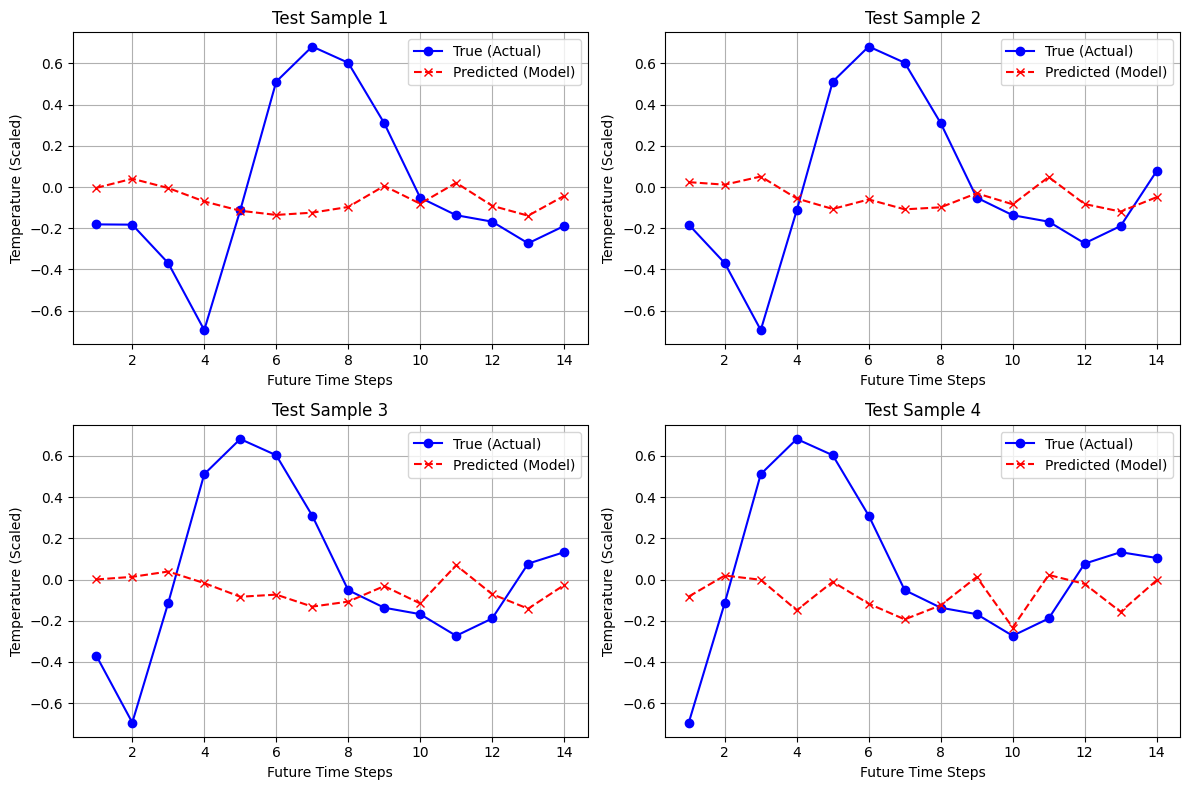

In [22]:
model.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()